In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
tracking_df = pd.read_csv("./data/embryo1/tracks.txt", sep="\t")


,t,z,y,x,cell_id,parent_id,track_id,radius,name,div_state
0,0,117.0,120.0,194.0,1,-1,1,30.5,AB,0
1,0,122.0,112.0,333.0,0,-1,0,17.5,P1,0
2,1,117.0,114.0,179.0,3,1,1,15.5,AB,0
3,1,118.0,115.0,333.0,2,0,0,17.5,P1,0
4,2,112.0,121.0,177.0,5,3,1,18.5,AB,0
...,...,...,...,...,...,...,...,...,...,...
110894,378,161.0,167.0,271.0,110786,110195,0,8.5,Cpapaa,0
110895,378,159.0,155.0,299.0,110414,109822,1,8.5,ABprapapaa,0
110896,378,151.0,156.0,328.0,110799,110209,0,6.5,Caaapp,0
110897,378,138.0,181.0,315.0,110790,110199,0,6.5,Cppppap,0


In [20]:
groups = tracking_df.groupby("name")
# for each group, calculate the distance traveled in the last 3 time points compared to the first 3 time points
# skip the first timepoint as it is too close to parent cell's division
movement_df = pd.DataFrame(columns=["distance_first3", "distance_after3", "time"])
for name, group in groups:
    group = group.sort_values("t")
    if len(group) < 7:
        continue
    distance_after3 = np.sqrt((group.iloc[-1]["x"] - group.iloc[3]["x"])**2 + (group.iloc[-1]["y"] - group.iloc[3]["y"])**2 + (group.iloc[-1]["z"] - group.iloc[3]["z"])**2)
    distance_first3 = np.sqrt((group.iloc[3]["x"] - group.iloc[0]["x"])**2 + (group.iloc[3]["y"] - group.iloc[0]["y"])**2 + (group.iloc[3]["z"] - group.iloc[0]["z"])**2)
    last_time = group.iloc[-1]["t"]
    movement_df.loc[name] = [distance_first3, distance_after3, last_time]

In [21]:
movement_df.sort_values("time")

,distance_first3,distance_after3,time
AB,15.842980,4.582576,6.0
P1,24.331050,32.511536,8.0
ABa,24.248711,25.806976,21.0
ABp,14.730920,37.656341,21.0
EMS,19.416488,46.658333,26.0
...,...,...,...
ABalaaaparr,6.708204,32.939338,378.0
ABalaaapalr,3.605551,90.260733,378.0
ABalaaapall,4.123106,51.088159,378.0
ABalaaaarrp,3.000000,17.029386,378.0


/tmp/ipykernel_3189547/3979530543.py:48: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_binned = movement_df.groupby('time_bin')[['distance_first3', 'distance_after3', 'distance_ratio']].mean()


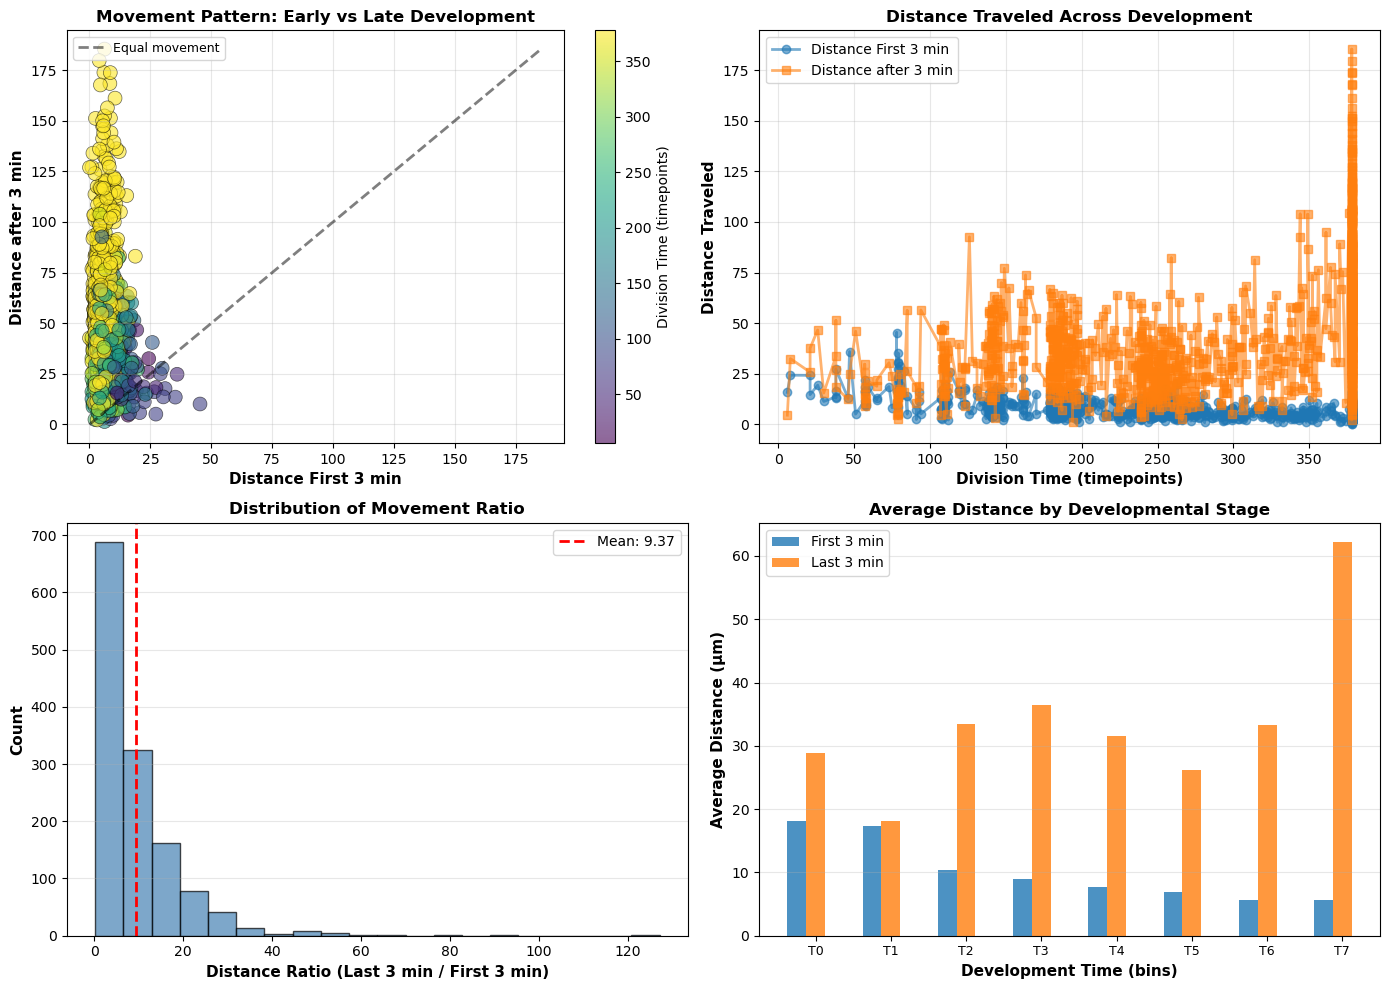


=== Summary Statistics ===
Total cells analyzed: 1330

Distance First 3 min:
  Mean: 7.14 μm
  Median: 6.16 μm
  Std Dev: 4.38 μm

Distance Last 3 min:


KeyError: 'distance_last3'

In [23]:
# Create comprehensive visualization of movement patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: Distance first 3 min vs Distance last 3 min, colored by division time
ax = axes[0, 0]
scatter = ax.scatter(movement_df['distance_first3'], movement_df['distance_after3'], 
                     c=movement_df['time'], cmap='viridis', alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
# Add x=y reference line
max_val = max(movement_df['distance_first3'].max(), movement_df['distance_after3'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, label='Equal movement')
ax.set_xlabel('Distance First 3 min', fontsize=11, fontweight='bold')
ax.set_ylabel('Distance after 3 min', fontsize=11, fontweight='bold')
ax.set_title('Movement Pattern: Early vs Late Development', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Division Time (timepoints)', fontsize=10)
ax.grid(alpha=0.3)

# 2. Time series: Distance first 3 and last 3 over development time
ax = axes[0, 1]
movement_sorted = movement_df.sort_values('time')
ax.plot(movement_sorted['time'], movement_sorted['distance_first3'], 'o-', label='Distance First 3 min', alpha=0.6, linewidth=2, markersize=6)
ax.plot(movement_sorted['time'], movement_sorted['distance_after3'], 's-', label='Distance after 3 min', alpha=0.6, linewidth=2, markersize=6)
ax.set_xlabel('Division Time (timepoints)', fontsize=11, fontweight='bold')
ax.set_ylabel('Distance Traveled', fontsize=11, fontweight='bold')
ax.set_title('Distance Traveled Across Development', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 3. Distribution of distance ratio (last 3 / first 3)
ax = axes[1, 0]
# Avoid division by zero and infinite values
movement_df['distance_ratio'] = movement_df['distance_after3'] / movement_df['distance_first3'].replace(0, np.nan)
ratio_valid = movement_df['distance_ratio'].dropna()
ratio_valid = ratio_valid[np.isfinite(ratio_valid)]
ax.hist(ratio_valid, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(ratio_valid.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {ratio_valid.mean():.2f}')
ax.set_xlabel('Distance Ratio (Last 3 min / First 3 min)', fontsize=11, fontweight='bold')
ax.set_ylabel('Count', fontsize=11, fontweight='bold')
ax.set_title('Distribution of Movement Ratio', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

# 4. Heatmap-style view: Bin cells by time and show average distances
ax = axes[1, 1]
# Create time bins for grouping
movement_df['time_bin'] = pd.cut(movement_df['time'], bins=8)
time_binned = movement_df.groupby('time_bin')[['distance_first3', 'distance_after3', 'distance_ratio']].mean()
x = np.arange(len(time_binned))
width = 0.25
ax.bar(x - width, time_binned['distance_first3'], width, label='First 3 min', alpha=0.8)
ax.bar(x, time_binned['distance_after3'], width, label='Last 3 min', alpha=0.8)
ax.set_xlabel('Development Time (bins)', fontsize=11, fontweight='bold')
ax.set_ylabel('Average Distance (μm)', fontsize=11, fontweight='bold')
ax.set_title('Average Distance by Developmental Stage', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'T{i}' for i in range(len(time_binned))], fontsize=9)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics ===")
print(f"Total cells analyzed: {len(movement_df)}")
print(f"\nDistance First 3 min:")
print(f"  Mean: {movement_df['distance_first3'].mean():.2f} μm")
print(f"  Median: {movement_df['distance_first3'].median():.2f} μm")
print(f"  Std Dev: {movement_df['distance_first3'].std():.2f} μm")
print(f"\nDistance Last 3 min:")
print(f"  Mean: {movement_df['distance_last3'].mean():.2f} μm")
print(f"  Median: {movement_df['distance_last3'].median():.2f} μm")
print(f"  Std Dev: {movement_df['distance_last3'].std():.2f} μm")
print(f"\nDistance Ratio (Last/First):")
print(f"  Mean: {ratio_valid.mean():.2f}")
print(f"  Median: {ratio_valid.median():.2f}")